# Train, predict, score, and evaluate a Hybrid Transformer on PLAsTiCC

This notebook uses your `dlip_plasticc` package on top of `avocado` to:

- train a `HybridTransformerClassifier`
- use both:
  - a sequence/light-curve branch
  - a Boone-style tabular feature branch
- predict on chunked PLAsTiCC test data
- compute the flat-weighted avocado logloss
- plot training history (`train_loss`, `val_loss`, `val_acc`)
- display a confusion matrix

In [4]:
# Notebook parameters

CONFIG_DEFAULT_PATH = '/home6/s4339150/Courses/dlip_plasticc/configs/default.toml'
CONFIG_LOCAL_PATH = '/home6/s4339150/Courses/dlip_plasticc/configs/local.toml'

# Training
TRAIN_DATASET_NAME = 'plasticc_augment'
CLASSIFIER_NAME = 'my_hybrid_transformer'
SEQ_LEN = 350
NUM_EPOCHS = 100
BATCH_SIZE = 64
LR = 1e-4
NUM_FOLDS = 5
RANDOM_STATE = 42
VAL_FOLD = 0
WEIGHT_DECAY = 1e-2
LR_SCHEDULER_FACTOR = 0.5
LR_SCHEDULER_PATIENCE = 2
MIN_LR = 1e-6
EARLY_STOPPING_PATIENCE = 20

# Hybrid Transformer architecture
D_MODEL = 128
BAND_EMB_DIM = 16
NHEAD = 4
NUM_LAYERS = 4
DIM_FEEDFORWARD = 256
DROPOUT = 0.2
NUM_BANDS = 6

# Prediction
TEST_DATASET_NAME = 'plasticc_test'
TOTAL_CHUNKS = 500
CHUNKS = range(21)
OUT_DIR = 'notebook_outputs/hybrid_transformer_predictions'

# Confusion matrix display options
CONFUSION_NORMALIZE = 'true'  # one of: None, 'true', 'pred', 'all'
FIGSIZE_HISTORY = (8, 5)
FIGSIZE_CONFUSION = (10, 8)


In [5]:
# Optional path helper for notebooks when the package is not installed yet.
import sys
from pathlib import Path

repo_root = Path.cwd()
if not (repo_root / 'src' / 'dlip_plasticc').exists():
    repo_root = repo_root.parent

src_path = repo_root / 'src'
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from tqdm import tqdm

import avocado

from dlip_plasticc.config import load_config, apply_avocado_settings
from dlip_plasticc.features import PlasticcSequenceFeaturizer
from dlip_plasticc.models import HybridTransformerClassifier
from dlip_plasticc.pipelines.score import score_flat, align_truth_and_predictions

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report


In [9]:
# Load config and push paths into avocado
cfg = load_config(CONFIG_DEFAULT_PATH, CONFIG_LOCAL_PATH)
apply_avocado_settings(cfg)

print('Using avocado paths:')
print('  data_directory       =', avocado.settings['data_directory'])
print('  features_directory   =', avocado.settings['features_directory'])
print('  predictions_directory=', avocado.settings['predictions_directory'])
print('  classifier_directory =', avocado.settings['classifier_directory'])


Using avocado paths:
  data_directory       = /scratch/s4339150/plasticc/data
  features_directory   = /scratch/s4339150/plasticc/features
  predictions_directory= /scratch/s4339150/plasticc/predictions
  classifier_directory = /scratch/s4339150/plasticc/classifiers


## 1. Set up featurizers and model

In [5]:
sequence_featurizer = PlasticcSequenceFeaturizer(seq_len=SEQ_LEN)
feature_featurizer = avocado.plasticc.PlasticcFeaturizer()

classifier = HybridTransformerClassifier(
    name=CLASSIFIER_NAME,
    sequence_featurizer=sequence_featurizer,
    feature_featurizer=feature_featurizer,
    num_epochs=NUM_EPOCHS,
    batch_size=BATCH_SIZE,
    lr=LR,
    d_model=D_MODEL,
    band_emb_dim=BAND_EMB_DIM,
    nhead=NHEAD,
    num_layers=NUM_LAYERS,
    dim_feedforward=DIM_FEEDFORWARD,
    dropout=DROPOUT,
    num_bands=NUM_BANDS,
)


## 2. Load training data and Boone raw features

In [6]:
print(f"Loading training dataset '{TRAIN_DATASET_NAME}'...")
train_dataset = avocado.load(TRAIN_DATASET_NAME)

print('Loading precomputed Boone raw features if available...')
try:
    train_dataset.load_raw_features()
    print('Loaded precomputed raw features.')
except Exception as exc:
    print('Could not load precomputed raw features. Computing them online instead.')
    print('Reason:', exc)
    train_dataset.extract_raw_features(feature_featurizer)
    print('Computed raw features online.')


Loading training dataset 'plasticc_augment'...
Loading precomputed Boone raw features if available...
Loaded precomputed raw features.


## 3. Train the Hybrid Transformer

In [7]:
classifier.train(
    train_dataset,
    num_folds=NUM_FOLDS,
    random_state=RANDOM_STATE,
    val_fold=VAL_FOLD,
    weight_decay=WEIGHT_DECAY,
    lr_scheduler_factor=LR_SCHEDULER_FACTOR,
    lr_scheduler_patience=LR_SCHEDULER_PATIENCE,
    min_lr=MIN_LR,
    early_stopping_patience=EARLY_STOPPING_PATIENCE,
    show_progress=True,
)

print(f"Best validation loss: {classifier.best_val_loss:.5f}")


Epochs:   0%|          | 0/100 [00:00<?, ?it/s]/home6/s4339150/miniconda/envs/project/lib/python3.10/site-packages/torch/nn/modules/transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(
Epochs:   1%|          | 1/100 [00:14<23:39, 14.34s/it]

Epoch 1 train_loss: 1.19969 val_loss: 0.83531 val_acc: 0.72429 lr: 1.000000e-04


Epochs:   2%|▏         | 2/100 [00:28<23:11, 14.20s/it]

Epoch 2 train_loss: 0.82626 val_loss: 0.73431 val_acc: 0.75151 lr: 1.000000e-04


Epochs:   3%|▎         | 3/100 [00:42<22:47, 14.10s/it]

...

Epoch 49 train_loss: 0.42646 val_loss: 0.53858 val_acc: 0.81876 lr: 1.000000e-06


Epochs:  50%|█████     | 50/100 [24:01<26:24, 31.70s/it]

Epoch 50 train_loss: 0.42515 val_loss: 0.53965 val_acc: 0.81816 lr: 1.000000e-06


Epochs:  50%|█████     | 50/100 [24:32<24:32, 29.45s/it]

Epoch 51 train_loss: 0.42370 val_loss: 0.53851 val_acc: 0.81876 lr: 1.000000e-06
Early stopping at epoch 51. Best val_loss: 0.53203
Best validation loss: 0.53203
Best validation loss: 0.53203


In [8]:
# Save the trained classifier
classifier.write(overwrite=True)
print('Classifier written to:', classifier.path)


Classifier written to: /scratch/s4339150/plasticc/classifiers/classifier_my_hybrid_transformer.pkl


## 4. Plot training history

In [9]:
history = classifier.history.copy()
history.tail()


,epoch,train_loss,val_loss,val_acc,lr
46,47,0.423114,0.539056,0.818386,0.000001
47,48,0.424027,0.539299,0.817937,0.000001
48,49,0.426463,0.538576,0.818760,0.000001
49,50,0.425154,0.539647,0.818161,0.000001
50,51,0.423704,0.538508,0.818760,0.000001


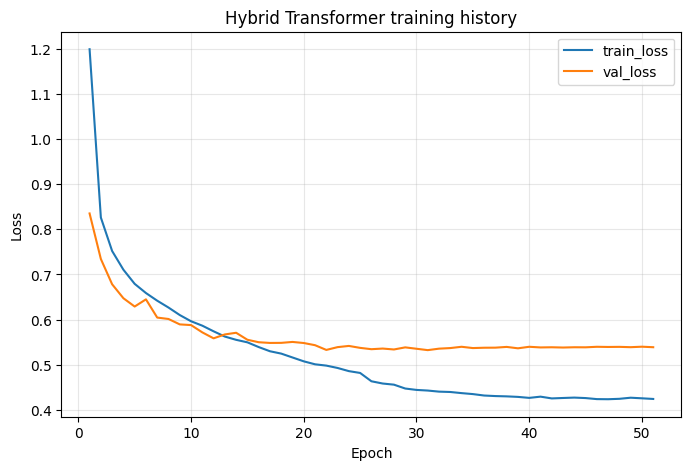

In [10]:
fig, ax = plt.subplots(figsize=FIGSIZE_HISTORY)
ax.plot(history['epoch'], history['train_loss'], label='train_loss')
ax.plot(history['epoch'], history['val_loss'], label='val_loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Hybrid Transformer training history')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()


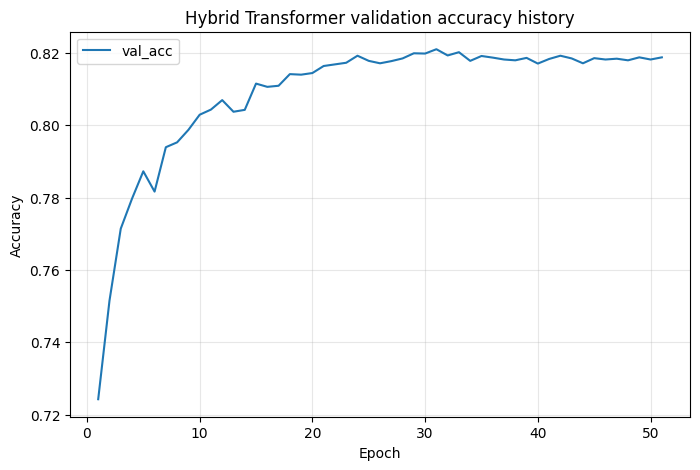

In [11]:
fig, ax = plt.subplots(figsize=FIGSIZE_HISTORY)
ax.plot(history['epoch'], history['val_acc'], label='val_acc')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.set_title('Hybrid Transformer validation accuracy history')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()


## 5. Predict on test chunks

For each chunk, we load full observations and compute Boone raw features online if needed.

In [10]:
classifier = avocado.load_classifier(CLASSIFIER_NAME)

In [16]:
Path(OUT_DIR).mkdir(parents=True, exist_ok=True)

all_preds = []
processed_chunks = []

for chunk in tqdm(CHUNKS, desc='Chunks', dynamic_ncols=True):
    print(f"\n=== Processing chunk {chunk}/{TOTAL_CHUNKS - 1} ===")

    dataset = avocado.load(
        TEST_DATASET_NAME,
        chunk=chunk,
        num_chunks=TOTAL_CHUNKS,
        metadata_only=False,
    )

    CHUNKS = list(range(21))   # 0 through 20
    FEATURES_TAG = "features"   
    dataset.load_raw_features(
    tag=FEATURES_TAG,
    verify_input_chunks=False,
    )
    print("  Loaded raw features from disk:", dataset.raw_features.shape)

    preds = classifier.predict(dataset)
    preds.index.name = 'object_id'

    out_path = Path(OUT_DIR) / f'predictions_chunk_{chunk}.h5'
    preds.to_hdf(out_path, key='predictions', mode='w')
    print(f'  Saved {len(preds):,} predictions to {out_path}')

    all_preds.append(preds)
    processed_chunks.append(chunk)

combined_predictions = pd.concat(all_preds).sort_index()
combined_predictions = combined_predictions[~combined_predictions.index.duplicated(keep='first')]
combined_predictions.index.name = 'object_id'

combined_path = Path(OUT_DIR) / 'predictions_combined.h5'
combined_predictions.to_hdf(combined_path, key='predictions', mode='w')

print('\nProcessed chunks:', processed_chunks)
print('Combined prediction shape:', combined_predictions.shape)
print('Saved combined predictions to:', combined_path)
combined_predictions.head()


Chunks:   0%|          | 0/21 [00:00<?, ?it/s]


=== Processing chunk 0/499 ===
  Loaded raw features from disk: (293, 230)


Chunks:   5%|▍         | 1/21 [00:09<03:17,  9.86s/it]

  Saved 6,985 predictions to notebook_outputs/hybrid_transformer_predictions/predictions_chunk_0.h5

=== Processing chunk 1/499 ===
  Loaded raw features from disk: (293, 230)


Chunks:  10%|▉         | 2/21 [00:19<03:07,  9.88s/it]

...

Chunks:  95%|█████████▌| 20/21 [02:35<00:07,  7.15s/it]

  Saved 6,986 predictions to notebook_outputs/hybrid_transformer_predictions/predictions_chunk_19.h5

=== Processing chunk 20/499 ===
  Loaded raw features from disk: (293, 230)


Chunks: 100%|██████████| 21/21 [02:42<00:00,  7.74s/it]

  Saved 6,986 predictions to notebook_outputs/hybrid_transformer_predictions/predictions_chunk_20.h5

Processed chunks: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
Combined prediction shape: (146701, 14)
Saved combined predictions to: notebook_outputs/hybrid_transformer_predictions/predictions_combined.h5


,6,15,16,42,52,53,62,64,65,67,88,90,92,95
object_id,,,,,,,,,,,,,,
plasticc_000000013,6.403079e-09,2.435532e-07,3.318599e-13,0.979016,0.010366,1.307211e-11,0.006213,4.905112e-10,1.492028e-10,0.000004,7.563341e-10,0.004340,1.668721e-14,0.000060
plasticc_000000014,3.338612e-10,1.638208e-05,1.883878e-12,0.624820,0.019610,3.011533e-11,0.002580,5.723294e-08,2.660158e-08,0.000111,2.129794e-07,0.352811,2.201746e-12,0.000051
plasticc_000000017,1.637453e-09,1.111960e-05,1.350037e-09,0.815163,0.009413,4.751274e-10,0.002033,3.800757e-05,2.000680e-05,0.000261,3.257446e-05,0.172792,1.358734e-09,0.000236
plasticc_000000023,5.877962e-10,8.990351e-07,5.563726e-12,0.027830,0.016147,6.512751e-11,0.033430,2.960527e-07,1.904002e-09,0.012727,1.379780e-07,0.909837,1.561783e-13,0.000029
plasticc_000000034,3.734625e-11,4.947490e-07,2.482992e-13,0.005500,0.021064,2.307623e-13,0.004769,2.683604e-08,1.520941e-09,0.001787,2.737320e-09,0.966877,9.983869e-16,0.000004


## 6. Score predictions with avocado flat-weighted logloss

In [17]:
flat_score, n_scored = score_flat(TEST_DATASET_NAME, combined_predictions)
print(f'Flat-weighted logloss: {flat_score:.5f}')
print(f'Objects scored:        {n_scored:,}')


Flat-weighted logloss: 3.92950
Objects scored:        146,085


In [19]:
y_true, pred_aligned = align_truth_and_predictions(
    TEST_DATASET_NAME,
    combined_predictions,
    known_classes_only=True,
    normalize=True,
)

print("y_true unique:", sorted(y_true.unique()))
print("pred columns:", list(pred_aligned.columns))
print("row sums min/max:", pred_aligned.sum(axis=1).min(), pred_aligned.sum(axis=1).max())
print("min prob:", pred_aligned.min().min())
print("max prob:", pred_aligned.max().max())

y_true unique: [np.int64(6), np.int64(15), np.int64(16), np.int64(42), np.int64(52), np.int64(53), np.int64(62), np.int64(64), np.int64(65), np.int64(67), np.int64(88), np.int64(90), np.int64(92), np.int64(95)]
pred columns: [6, 15, 16, 42, 52, 53, 62, 64, 65, 67, 88, 90, 92, 95]
row sums min/max: 0.99999976 1.0000002
min prob: 7.4392633e-16
max prob: 0.99998313


In [20]:
print(pred_aligned.idxmax(axis=1).value_counts().sort_index())

6      1413
15     1365
16     3405
42    30485
52       49
53       51
62        6
64       19
65    98939
67        4
88     1371
90     3002
92     5975
95        1
Name: count, dtype: int64


In [21]:
print(y_true.value_counts().sort_index())

class
6        43
15      479
16     3233
42    48142
52     2864
53       46
62     7859
64        8
65     3095
67     1673
88     3743
90    66848
92     6781
95     1271
Name: count, dtype: int64


## 7. Confusion matrix

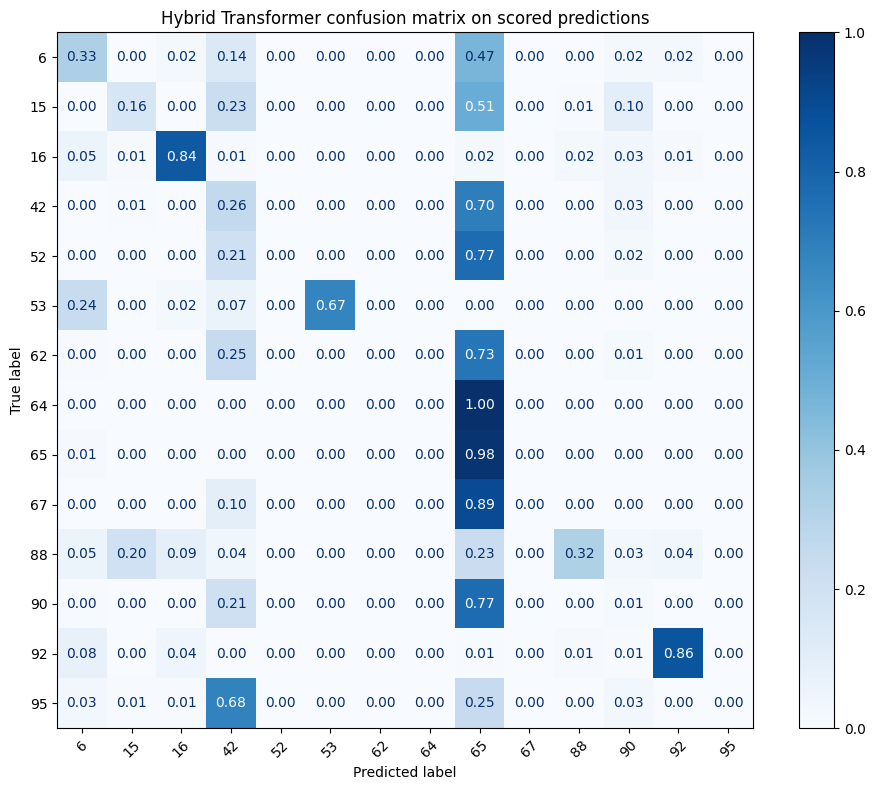

In [18]:
y_true, pred_aligned = align_truth_and_predictions(
    TEST_DATASET_NAME,
    combined_predictions,
    known_classes_only=True,
    normalize=True,
)

y_pred = pred_aligned.idxmax(axis=1)
labels = sorted(np.unique(np.concatenate([y_true.values, y_pred.values])))

cm = confusion_matrix(y_true, y_pred, labels=labels, normalize=CONFUSION_NORMALIZE)

fig, ax = plt.subplots(figsize=FIGSIZE_CONFUSION)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(ax=ax, xticks_rotation=45, colorbar=True, cmap='Blues', values_format='.2f')
ax.set_title('Hybrid Transformer confusion matrix on scored predictions')
plt.tight_layout()
plt.show()


In [ ]:
print(classification_report(y_true, y_pred, digits=4))


## 8. Optional: Save combined predictions to CSV

In [ ]:
csv_path = Path(OUT_DIR) / 'predictions_combined.csv'
combined_predictions.to_csv(csv_path)
print('Wrote:', csv_path)
